# Retail Sales Data – Exploratory Data Analysis

## OASIS Infobyte Internship – Data Analytics

### Objective

To perform Exploratory Data Analysis (EDA) on retail sales data to identify sales trends, customer behaviour patterns, product performance, and actionable business insights.

### Tools and Technologies

- Python
- Pandas
- Matplotlib
- Seaborn
- JupyterLab

## Dataset Information

The dataset contains retail transaction records with information about customers, products, quantities, prices, and total transaction amounts.

The main columns used in this analysis include:

- **Transaction ID** – Unique identifier for each transaction
- **Date** – Date of the transaction
- **Customer ID** – Unique identifier for each customer
- **Gender** – Customer gender
- **Age** – Customer age
- **Product Category** – Category of the purchased product
- **Quantity** – Number of units purchased
- **Price per Unit** – Price of one unit
- **Total Amount** – Total transaction value

## 1. Data Loading and Initial Inspection

The retail sales dataset is loaded using Pandas...

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## 2. Descriptive Statistics

Descriptive statistics are used to understand the central tendency and spread of the numerical variables in the dataset. Mean, median, mode, and standard deviation are calculated to summarize customer age, quantity purchased, price per unit, and total transaction amount.

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [9]:
df.mode(numeric_only=True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

## 3. Time Series Analysis

Time series analysis is performed to understand how retail sales change over time. Monthly and quarterly sales trends are visualized to identify periods of high and low sales activity.

In [12]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

In [13]:
import matplotlib.pyplot as plt

### 3.1 Monthly Sales Trend

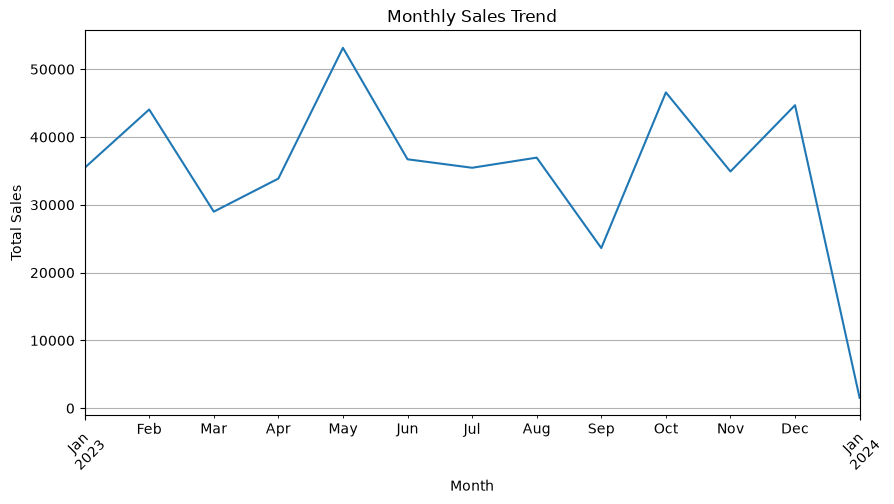

In [14]:
monthly_sales.plot(kind='line', figsize=(10, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales show considerable fluctuations throughout the year. Sales reached their highest level in May, while September recorded a significant decline. Sales recovered strongly in October before fluctuating again in the following months. The low value in January 2024 may be due to limited data for that month.

### 3.2 Quarterly Sales Trend

In [15]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

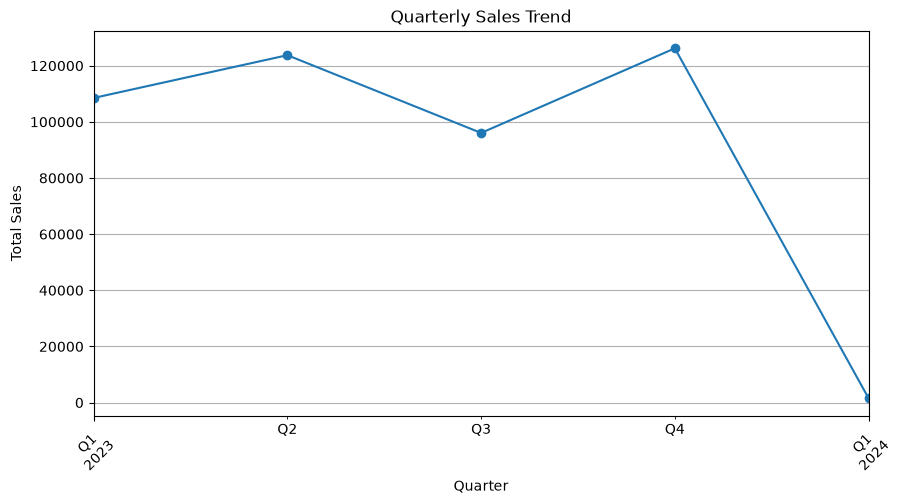

In [16]:
quarterly_sales.plot(kind='line', marker='o', figsize=(10, 5))

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Observation – Quarterly Sales Trend

Quarterly sales show fluctuations throughout the year. Sales increased from Q1 to Q2 2023, followed by a decline in Q3. Q4 2023 recorded the highest quarterly sales, indicating strong performance toward the end of the year. The very low Q1 2024 value is likely because the dataset contains only limited data for January 2024.

## 4. Customer Demographics

In [17]:
bins = [0, 25, 35, 50, 65, 100]
labels = ['18-25', '26-35', '36-50', '51-65', '66+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

### 4.1 Age Group Analysis

In [18]:
age_counts = df['Age Group'].value_counts().sort_index()
age_counts

Age Group
18-25    169
26-35    205
36-50    313
51-65    313
66+        0
Name: count, dtype: int64

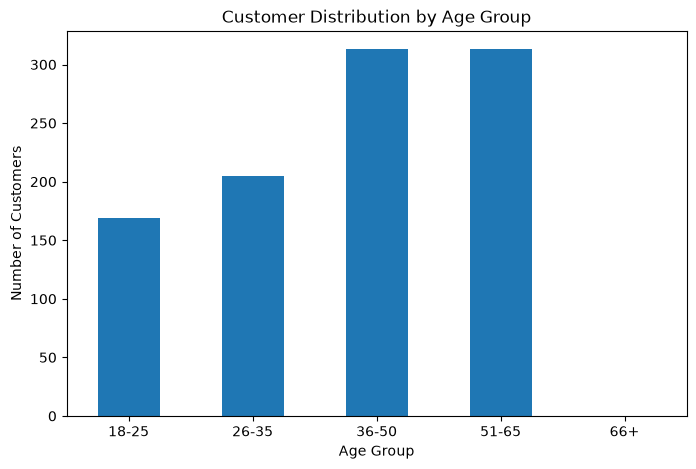

In [19]:
age_counts.plot(kind='bar', figsize=(8, 5))

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [20]:
age_counts.idxmax(), age_counts.max()

('36-50', np.int64(313))

In [21]:
age_counts.idxmin(), age_counts.min()

('66+', np.int64(0))

### Observation – Customer Age Distribution

The 36–50 and 51-65 age group has the highest number of customers, with 313 customers, making it the dominant age segment in the dataset. The 66+ age group has no customers, indicating that senior customers are not represented in this dataset. The business can focus its marketing efforts on the 36–50 age group while considering separate strategies to attract older customers.


### 4.2 Gender Analysis

In [22]:
gender_counts = df['Gender'].value_counts()
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

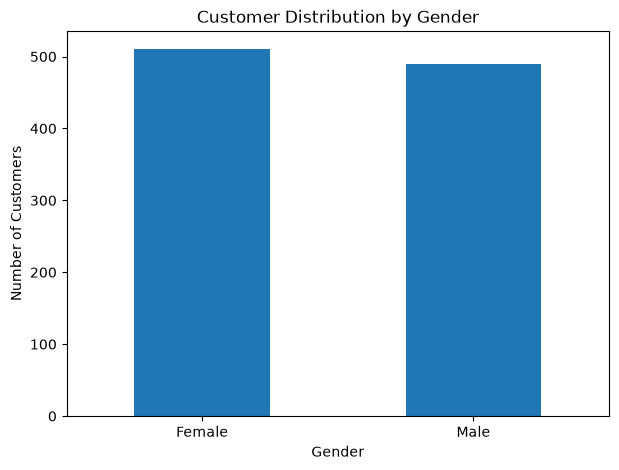

In [23]:
gender_counts.plot(kind='bar', figsize=(7, 5))

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [24]:
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

### Observation – Gender Distribution

The gender distribution shows the number of male and female customers in the dataset. The two groups have relatively similar representation, indicating that the retail business serves both male and female customers. Therefore, marketing strategies can target both genders rather than focusing exclusively on one group.


## 5. Product Analysis

In [25]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

### 5.1 Revenue by Product Category

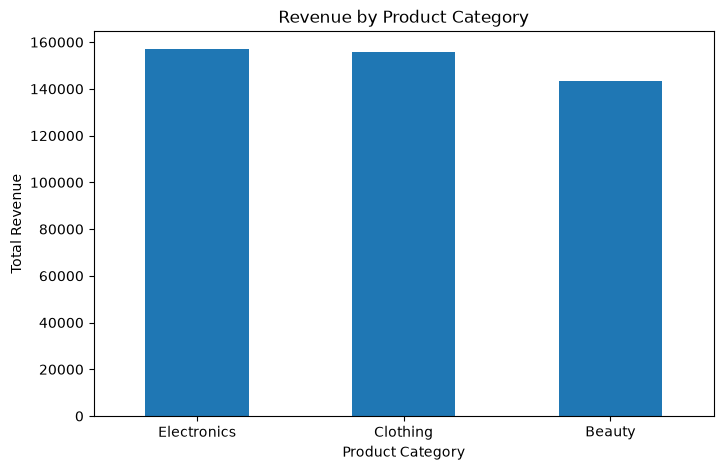

In [26]:
category_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

In [27]:
category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

### Observation – Revenue by Product Category

The revenue generated by the product categories varies across the dataset. The category with the highest revenue represents the strongest contributor to overall sales, while the category with the lowest revenue may require additional promotional attention. Understanding category-level revenue helps the business allocate marketing resources and focus on high-performing product segments.

### 5.2 Best-Selling Product Categories

In [28]:
top_categories = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
top_categories

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

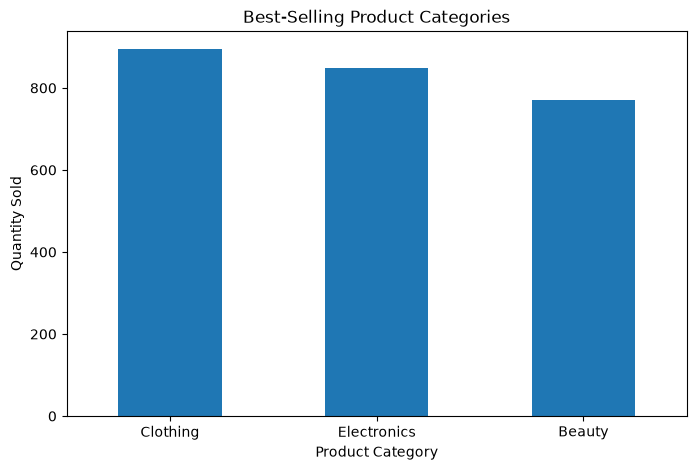

In [29]:
top_categories.plot(kind='bar', figsize=(8, 5))

plt.title('Best-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.show()

### Observation – Best-Selling Product Categories

The chart compares the total quantity sold across product categories. The category with the highest quantity sold represents the strongest demand, while categories with lower quantities may have opportunities for improvement through promotions, discounts, or better product positioning.

## 6. Correlation Analysis

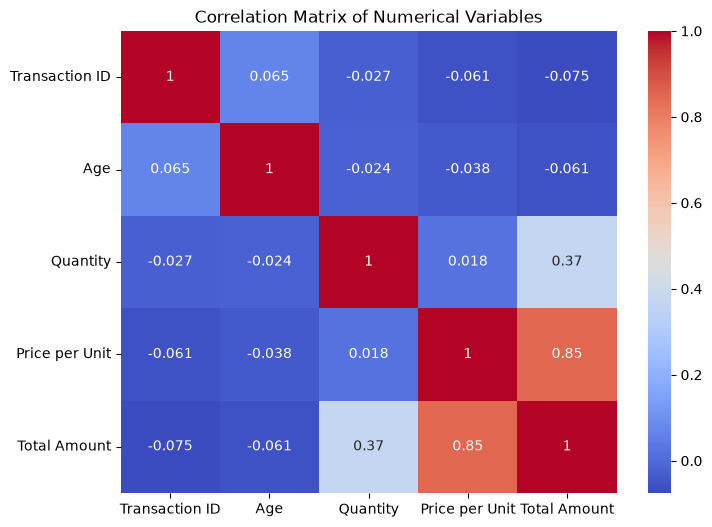

In [30]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observation – Correlation Analysis

The correlation matrix shows that Price per Unit has a strong positive correlation with Total Amount (0.85), indicating that transactions with higher-priced products tend to generate higher sales amounts. Quantity has a moderate positive correlation with Total Amount (0.37), meaning that purchasing more items also contributes to higher sales. Age has very weak correlations with the sales variables, suggesting that customer age has little direct linear relationship with sales amount. Transaction ID is an identifier and therefore its correlations are not useful for business interpretation.


## 7. Additional Analysis

In [31]:
age_group_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()
age_group_sales

Age Group
18-25     84550
26-35     98480
36-50    139660
51-65    133310
Name: Total Amount, dtype: int64

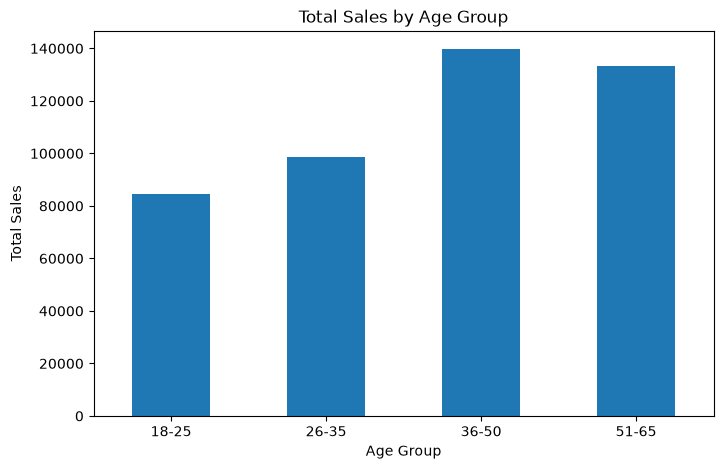

In [32]:
age_group_sales.plot(kind='bar', figsize=(8, 5))

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Observation – Sales by Age Group

The sales distribution across age groups shows how customer demographics contribute to revenue. Comparing the sales generated by each age group with the number of customers helps identify valuable customer segments. This analysis can help the business focus marketing campaigns and offers on age groups that contribute more revenue.

# 8. Conclusion and Business Recommendations

## Key Findings

1. Monthly and quarterly sales show significant fluctuations, with strong performance during May and Q4 2023.
2. Customers in the 36–50 and 51-65 age group form the largest customer segment in the dataset.
3. Price per Unit has a strong positive correlation with Total Amount (0.85), while Quantity has a moderate positive correlation (0.37).
4. Revenue and sales quantity vary across product categories, indicating different levels of customer demand.
5. The analysis of sales by age group helps identify which customer segments contribute more to overall revenue.

## Business Recommendations

1. **Focus on high-performing periods:** The business should prepare additional inventory and targeted promotions before periods that historically show strong sales, particularly Q4.
2. **Target the 36–50 age group:** Since this is the largest customer segment, personalized offers and marketing campaigns can be designed to increase customer engagement and repeat purchases.
3. **Optimize product pricing and promotions:** Since Price per Unit has a strong relationship with Total Amount, the business should carefully analyze pricing, discounts, and premium product offerings to maximize revenue.

## Final Conclusion

The exploratory data analysis provides useful insights into sales trends, customer demographics, product categories, and relationships between numerical variables. The findings can help the business make better decisions about marketing, pricing, inventory planning, and customer targeting. Further analysis with a larger dataset containing more detailed product and customer information could provide deeper insights into customer purchasing behaviour.